# 04 — Random Forest LST Downscaling

## Objective

This notebook implements the Random Forest stage of the LST downscaling workflow for Lucknow.

The model is trained using the 90 m coarse-resolution LST generated during the spatial degradation experiment and spatially matched remote-sensing predictors.

The trained model is then applied to the 30 m predictor datasets to generate a 30 m Random Forest-based LST product.

### Predictors

- Green reflectance
- SWIR1 reflectance
- SWIR2 reflectance
- NDVI
- NDBI
- MNDWI

### Target

- 90 m coarse-resolution LST

### Workflow

90 m predictors + 90 m LST
        ↓
Training dataset
        ↓
Random Forest regression
        ↓
Trained model
        ↓
30 m predictors
        ↓
30 m RF LST
        ↓
Evaluation and spatial analysis

In [77]:
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

from pathlib import Path

In [78]:
PROJECT_DIR = Path(r"D:\Projects\GeoAI-LST-Downscaling")

FINE_DIR = PROJECT_DIR / "data" / "processed" / "lucknow" / "fine"
COARSE_DIR = PROJECT_DIR / "data" / "processed" / "lucknow" / "coarse"

In [79]:
print("Fine directory:", FINE_DIR)
print("Coarse directory:", COARSE_DIR)

print("\nFine directory exists:", FINE_DIR.exists())
print("Coarse directory exists:", COARSE_DIR.exists())

Fine directory: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\fine
Coarse directory: D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\coarse

Fine directory exists: True
Coarse directory exists: True


In [80]:
predictor_paths = {
    "green": FINE_DIR / "predictors"/ "green_lucknow_reflectance.tif",
    "swir1": FINE_DIR / "predictors"/ "swir1_lucknow_reflectance.tif",
    "swir2": FINE_DIR / "predictors"/ "swir2_lucknow_reflectance.tif",
    "ndvi": FINE_DIR / "predictors"/ "ndvi_lucknow.tif",
    "ndbi": FINE_DIR / "predictors"/ "ndbi_lucknow.tif",
    "mndwi": FINE_DIR / "predictors"/ "mndwi_lucknow.tif"
}

lst_90m_path = COARSE_DIR / "lst_90m_lucknow.tif"

In [81]:
for name, path in predictor_paths.items():
    print(f"{name:6}:", path.exists(), "->", path.name)

print(f"{'lst_90m':6}:", lst_90m_path.exists(), "->", lst_90m_path.name)

green : True -> green_lucknow_reflectance.tif
swir1 : True -> swir1_lucknow_reflectance.tif
swir2 : True -> swir2_lucknow_reflectance.tif
ndvi  : True -> ndvi_lucknow.tif
ndbi  : True -> ndbi_lucknow.tif
mndwi : True -> mndwi_lucknow.tif
lst_90m: True -> lst_90m_lucknow.tif


In [82]:
def raster_info(path):
    with rasterio.open(path) as src:
        return {
            "shape": src.shape,
            "crs": src.crs,
            "resolution": src.res,
            "transform": src.transform,
            "nodata": src.nodata,
            "dtype": src.dtypes[0]
        }

In [83]:
for name, path in predictor_paths.items():
    print(f"\n{name.upper()}")
    print(raster_info(path))

print("\nLST 90M")
print(raster_info(lst_90m_path))


GREEN
{'shape': (703, 762), 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32644"]]'), 'resolution': (30.0, 30.0), 'transform': Affine(30.0, 0.0, 483225.0,
       0.0, -30.0, 2979165.0), 'nodata': 0.0, 'dtype': 'uint16'}

SWIR1
{'shape': (703, 762), 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 44N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["G

In [84]:
for name in ["green", "swir1", "swir2"]:
    path = predictor_paths[name]

    with rasterio.open(path) as src:
        data = src.read(1)

        valid = data[data != src.nodata]

        print(f"\n{name.upper()}")
        print("Minimum:", valid.min())
        print("Maximum:", valid.max())
        print("Mean:", valid.mean())
        print("Sample:", valid[:10])


GREEN
Minimum: 9558
Maximum: 22311
Mean: 11894.272034886122
Sample: [12313 12133 11511 12681 12241 12956 12187 12107 12354 12508]

SWIR1
Minimum: 9585
Maximum: 44110
Mean: 15944.454313600316
Sample: [15714 15794 14974 16602 16177 16975 16151 16359 16267 17382]

SWIR2
Minimum: 8647
Maximum: 36440
Mean: 13794.29430559658
Sample: [13492 13704 12470 14222 14021 14793 13970 13864 13891 15115]


In [85]:
for name in ["ndvi", "ndbi", "mndwi"]:
    path = predictor_paths[name]

    with rasterio.open(path) as src:
        data = src.read(1)

        valid = data[data != src.nodata]

        print(f"\n{name.upper()}")
        print("Minimum:", valid.min())
        print("Maximum:", valid.max())
        print("Mean:", valid.mean())
        print("Sample:", valid[:10])


NDVI
Minimum: nan
Maximum: nan
Mean: nan
Sample: [nan nan nan nan nan nan nan nan nan nan]

NDBI
Minimum: nan
Maximum: nan
Mean: nan
Sample: [nan nan nan nan nan nan nan nan nan nan]

MNDWI
Minimum: nan
Maximum: nan
Mean: nan
Sample: [nan nan nan nan nan nan nan nan nan nan]


In [86]:
for name in ["ndvi", "ndbi", "mndwi"]:
    path = predictor_paths[name]

    with rasterio.open(path) as src:
        data = src.read(1)

        valid = data[np.isfinite(data)]

        print(f"\n{name.upper()}")
        print("Minimum:", valid.min())
        print("Maximum:", valid.max())
        print("Mean:", valid.mean())
        print("Sample:", valid[:10])


NDVI
Minimum: 0.027113719
Maximum: 0.77813345
Mean: 0.30725604
Sample: [0.27733564 0.2890919  0.37117758 0.25204042 0.26111844 0.22279169
 0.27406496 0.31534815 0.27450246 0.2691093 ]

NDBI
Minimum: -0.52347004
Maximum: 0.013186339
Mean: -0.2225873
Sample: [-0.25027728 -0.24023476 -0.26125002 -0.23645711 -0.22110347 -0.23143528
 -0.22927156 -0.24951395 -0.23779847 -0.22578059]

MNDWI
Minimum: -0.3281944
Maximum: 0.06609564
Mean: -0.14413378
Sample: [-0.12134727 -0.13109177 -0.13075326 -0.13390021 -0.13850376 -0.1342755
 -0.13988285 -0.14937118 -0.1367178  -0.16306457]


### 1. Prepare 90 m Predictor Data

The machine-learning model will be trained using the 90 m coarse-resolution LST as the target.

The 30 m predictor rasters are aggregated to the exact spatial grid of the 90 m LST using 3 × 3 blocks.

Only finite/valid predictor values are included when calculating block means.

In [87]:
with rasterio.open(lst_90m_path) as src:
    lst_90m = src.read(1)
    coarse_profile = src.profile.copy()
    coarse_transform = src.transform
    coarse_crs = src.crs
    coarse_shape = src.shape

print("Coarse LST shape:", coarse_shape)
print("Coarse LST resolution:", src.res)
print("Coarse LST CRS:", coarse_crs)
print("Coarse LST transform:", coarse_transform)

Coarse LST shape: (234, 254)
Coarse LST resolution: (90.0, 90.0)
Coarse LST CRS: EPSG:32644
Coarse LST transform: | 90.00, 0.00, 483225.00|
| 0.00,-90.00, 2979165.00|
| 0.00, 0.00, 1.00|


In [88]:
def aggregate_30m_to_90m(data, nodata=None):
    """
    Aggregate a 30 m raster to 90 m using 3x3 valid-pixel means.

    The input must have dimensions compatible with a 3x3 aggregation.
    """

    # Remove the incomplete final row
    data = data[:702, :762]

    # Reshape into 3x3 blocks
    reshaped = data.reshape(234, 3, 254, 3)

    # Treat non-finite values as invalid
    valid = np.isfinite(reshaped)

    # Sum only valid values
    data_clean = np.where(valid, reshaped, 0)

    value_sum = data_clean.sum(axis=(1, 3))
    valid_count = valid.sum(axis=(1, 3))

    # Calculate mean only where at least one valid pixel exists
    result = np.full((234, 254), np.nan, dtype=np.float32)

    valid_blocks = valid_count > 0

    result[valid_blocks] = (
        value_sum[valid_blocks] /
        valid_count[valid_blocks]
    )

    return result

In [89]:
predictors_90m = {}

for name, path in predictor_paths.items():

    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)

    predictors_90m[name] = aggregate_30m_to_90m(data)

    print(
        f"{name.upper():6} | "
        f"shape = {predictors_90m[name].shape} | "
        f"min = {np.nanmin(predictors_90m[name]):.6f} | "
        f"max = {np.nanmax(predictors_90m[name]):.6f} | "
        f"mean = {np.nanmean(predictors_90m[name]):.6f}"
    )

GREEN  | shape = (234, 254) | min = 0.000000 | max = 17696.111328 | mean = 7000.895508
SWIR1  | shape = (234, 254) | min = 0.000000 | max = 28746.445312 | mean = 9384.808594
SWIR2  | shape = (234, 254) | min = 0.000000 | max = 27468.888672 | mean = 8119.237305
NDVI   | shape = (234, 254) | min = 0.102692 | max = 0.741849 | mean = 0.308028
NDBI   | shape = (234, 254) | min = -0.460101 | max = -0.009748 | mean = -0.222936
MNDWI  | shape = (234, 254) | min = -0.245560 | max = 0.051391 | mean = -0.144368


In [90]:
for name, data in predictors_90m.items():

    print(f"\n{name.upper()}")

    print("Same shape:",
          data.shape == lst_90m.shape)

    print("Valid predictor pixels:",
          np.isfinite(data).sum())

    print("Valid LST pixels:",
          np.isfinite(lst_90m).sum())


GREEN
Same shape: True
Valid predictor pixels: 59436
Valid LST pixels: 59436

SWIR1
Same shape: True
Valid predictor pixels: 59436
Valid LST pixels: 59436

SWIR2
Same shape: True
Valid predictor pixels: 59436
Valid LST pixels: 59436

NDVI
Same shape: True
Valid predictor pixels: 35392
Valid LST pixels: 59436

NDBI
Same shape: True
Valid predictor pixels: 35392
Valid LST pixels: 59436

MNDWI
Same shape: True
Valid predictor pixels: 35392
Valid LST pixels: 59436


In [91]:
print("LST transform:")
print(coarse_transform)

print("\nExpected 90 m transform:")
print(rasterio.Affine(90, 0, 483225,
                      0, -90, 2979165))

LST transform:
| 90.00, 0.00, 483225.00|
| 0.00,-90.00, 2979165.00|
| 0.00, 0.00, 1.00|

Expected 90 m transform:
| 90.00, 0.00, 483225.00|
| 0.00,-90.00, 2979165.00|
| 0.00, 0.00, 1.00|


### Observation

The 30 m predictor variables were successfully aggregated to the 90 m LST grid using valid-pixel means. Green, SWIR1, and SWIR2 were treated with a NoData value of 0, while the spectral indices were handled using NaN-based validity masking.

The resulting predictor rasters share the same 90 m spatial grid as the coarse LST target, allowing pixel-wise construction of the machine-learning dataset.

### 2. Build the Machine-Learning Dataset

A common validity mask is applied so that each training observation contains valid values for all predictor variables and the 90 m LST target.

In [92]:
# Start with all pixels considered invalid
common_mask = (
    np.isfinite(lst_90m)
    & (lst_90m != -9999)
)

# Require valid values for every predictor
for name, data in predictors_90m.items():
    common_mask &= np.isfinite(data)

print("Total 90 m pixels:", lst_90m.size)
print("Valid ML pixels:", common_mask.sum())
print("Invalid ML pixels:", (~common_mask).sum())
print(
    "Valid percentage:",
    common_mask.sum() / lst_90m.size * 100
)

Total 90 m pixels: 59436
Valid ML pixels: 35383
Invalid ML pixels: 24053
Valid percentage: 59.531260515512486


In [93]:
X = np.column_stack([
    predictors_90m["green"][common_mask],
    predictors_90m["swir1"][common_mask],
    predictors_90m["swir2"][common_mask],
    predictors_90m["ndvi"][common_mask],
    predictors_90m["ndbi"][common_mask],
    predictors_90m["mndwi"][common_mask]
])

y = lst_90m[common_mask]

In [94]:
feature_names = [
    "green",
    "swir1",
    "swir2",
    "ndvi",
    "ndbi",
    "mndwi"
]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", feature_names)

X shape: (35383, 6)
y shape: (35383,)
Features: ['green', 'swir1', 'swir2', 'ndvi', 'ndbi', 'mndwi']


In [95]:
df = pd.DataFrame(X, columns=feature_names)

df["lst_90m"] = y

print(df.shape)
df.head()

(35383, 7)


,green,swir1,swir2,ndvi,ndbi,mndwi,lst_90m
0,5521.555664,7450.222168,6327.555664,0.299937,-0.249295,-0.148870,38.412750
1,11060.333008,14704.777344,12696.111328,0.268907,-0.233988,-0.141156,38.404633
2,9576.555664,13015.000000,11232.444336,0.289513,-0.235025,-0.151708,38.259674
3,8424.111328,11847.000000,10552.111328,0.238129,-0.204983,-0.168680,38.722076
4,4236.777832,5784.333496,5053.333496,0.255982,-0.231062,-0.154385,38.366608


In [96]:
print("NaN values:")
print(df.isna().sum())

print("\nInfinite values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum())

NaN values:
green      0
swir1      0
swir2      0
ndvi       0
ndbi       0
mndwi      0
lst_90m    0
dtype: int64

Infinite values:
green      0
swir1      0
swir2      0
ndvi       0
ndbi       0
mndwi      0
lst_90m    0
dtype: int64


In [97]:
print("\nDataset summary:")
print(df.describe())


Dataset summary:
              green         swir1         swir2          ndvi          ndbi  \
count  35383.000000  35383.000000  35383.000000  35383.000000  35383.000000   
mean   11757.093750  15760.546875  13635.253906      0.308015     -0.222933   
std     1216.709839   1858.509399   1760.192261      0.111531      0.048858   
min     1108.888916   1215.111084   1068.444458      0.102692     -0.460101   
25%    11491.166504  15152.333008  13050.055664      0.225823     -0.249635   
50%    12012.444336  15874.444336  13932.777344      0.286040     -0.217931   
75%    12336.111328  16511.555664  14470.555664      0.363555     -0.189081   
max    17696.111328  28746.445312  27468.888672      0.741849     -0.009748   

              mndwi       lst_90m  
count  35383.000000  35383.000000  
mean      -0.144368     39.171635  
std        0.027332      1.490392  
min       -0.245560     32.283291  
25%       -0.160215     38.454334  
50%       -0.139314     39.309586  
75%       -0.12596

In [98]:
def aggregate_30m_to_90m(data, nodata=None):
    """
    Aggregate a 30 m raster to 90 m using 3x3
    valid-pixel means.
    """

    # Keep the 702 x 762 region used by the coarse LST
    data = data[:702, :762]

    # Create 3x3 blocks
    reshaped = data.reshape(234, 3, 254, 3)

    # Validity mask
    valid = np.isfinite(reshaped)

    if nodata is not None:
        valid &= reshaped != nodata

    # Replace invalid values with zero for summation
    data_clean = np.where(valid, reshaped, 0)

    value_sum = data_clean.sum(axis=(1, 3))
    valid_count = valid.sum(axis=(1, 3))

    result = np.full(
        (234, 254),
        np.nan,
        dtype=np.float32
    )

    valid_blocks = valid_count > 0

    result[valid_blocks] = (
        value_sum[valid_blocks]
        / valid_count[valid_blocks]
    )

    return result

In [99]:
predictor_nodata = {
    "green": 0,
    "swir1": 0,
    "swir2": 0,
    "ndvi": None,
    "ndbi": None,
    "mndwi": None
}

In [100]:
predictors_90m = {}

for name, path in predictor_paths.items():

    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)

    predictors_90m[name] = aggregate_30m_to_90m(
        data,
        nodata=predictor_nodata[name]
    )

    print(
        f"{name.upper():6} | "
        f"shape = {predictors_90m[name].shape} | "
        f"min = {np.nanmin(predictors_90m[name]):.6f} | "
        f"max = {np.nanmax(predictors_90m[name]):.6f} | "
        f"mean = {np.nanmean(predictors_90m[name]):.6f}"
    )

GREEN  | shape = (234, 254) | min = 9628.222656 | max = 17696.111328 | mean = 11892.142578


SWIR1  | shape = (234, 254) | min = 9818.888672 | max = 28746.445312 | mean = 15949.316406
SWIR2  | shape = (234, 254) | min = 8984.111328 | max = 27468.888672 | mean = 13793.961914
NDVI   | shape = (234, 254) | min = 0.102692 | max = 0.741849 | mean = 0.308028
NDBI   | shape = (234, 254) | min = -0.460101 | max = -0.009748 | mean = -0.222936
MNDWI  | shape = (234, 254) | min = -0.245560 | max = 0.051391 | mean = -0.144368


In [101]:
common_mask = (
    np.isfinite(lst_90m)
    & (lst_90m != -9999)
)

for name, data in predictors_90m.items():
    common_mask &= np.isfinite(data)


X = np.column_stack([
    predictors_90m["green"][common_mask],
    predictors_90m["swir1"][common_mask],
    predictors_90m["swir2"][common_mask],
    predictors_90m["ndvi"][common_mask],
    predictors_90m["ndbi"][common_mask],
    predictors_90m["mndwi"][common_mask]
])

y = lst_90m[common_mask]

df = pd.DataFrame(X, columns=feature_names)
df["lst_90m"] = y

In [102]:
print("Total 90 m pixels:", lst_90m.size)
print("Valid ML pixels:", common_mask.sum())
print("Invalid ML pixels:", (~common_mask).sum())
print(
    "Valid percentage:",
    common_mask.sum() / lst_90m.size * 100
)

print("\nNaN values:")
print(df.isna().sum())

print("\nInfinite values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum())

print("\nDataset summary:")
print(df.describe())

Total 90 m pixels: 59436
Valid ML pixels: 35383
Invalid ML pixels: 24053
Valid percentage: 59.531260515512486

NaN values:
green      0
swir1      0
swir2      0
ndvi       0
ndbi       0
mndwi      0
lst_90m    0
dtype: int64

Infinite values:
green      0
swir1      0
swir2      0
ndvi       0
ndbi       0
mndwi      0
lst_90m    0
dtype: int64

Dataset summary:
              green         swir1         swir2          ndvi          ndbi  \
count  35383.000000  35383.000000  35383.000000  35383.000000  35383.000000   
mean   11892.228516  15949.416016  13794.112305      0.308015     -0.222933   
std      675.622681   1313.263794   1330.670776      0.111531      0.048858   
min     9628.222656   9818.888672   8984.111328      0.102692     -0.460101   
25%    11538.611328  15220.555664  13138.388672      0.225823     -0.249635   
50%    12026.000000  15909.666992  13958.111328      0.286040     -0.217931   
75%    12341.055664  16554.278320  14487.222656      0.363555     -0.189081   
m

In [103]:
rows, cols = np.where(common_mask)

print("Number of spatial observations:", len(rows))
print("Row range:", rows.min(), "to", rows.max())
print("Column range:", cols.min(), "to", cols.max())

Number of spatial observations: 35383
Row range: 0 to 233
Column range: 0 to 253


In [104]:
BLOCK_SIZE = 30

block_rows = rows // BLOCK_SIZE
block_cols = cols // BLOCK_SIZE

block_ids = (
    block_rows * (254 // BLOCK_SIZE + 1)
    + block_cols
)

print("Number of unique spatial blocks:", np.unique(block_ids).size)

Number of unique spatial blocks: 55


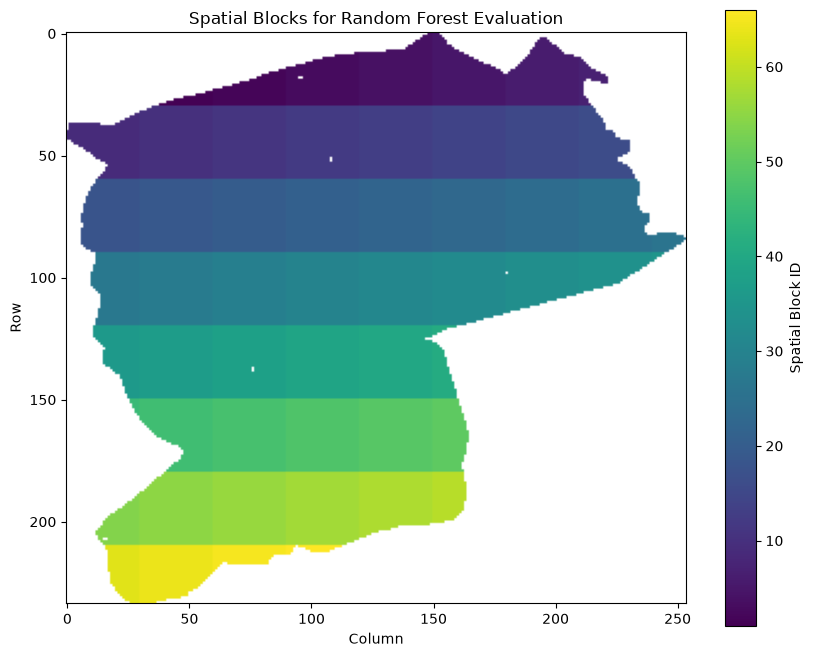

In [105]:
# Create a 2D map of spatial block IDs
block_map = np.full(lst_90m.shape, np.nan)

block_map[common_mask] = block_ids

plt.figure(figsize=(10, 8))
plt.imshow(block_map, origin="upper")
plt.colorbar(label="Spatial Block ID")
plt.title("Spatial Blocks for Random Forest Evaluation")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

In [106]:
block_counts = pd.Series(block_ids).value_counts().sort_index()

print(block_counts)
print("\nNumber of blocks:", len(block_counts))
print("Minimum pixels per block:", block_counts.min())
print("Maximum pixels per block:", block_counts.max())
print("Mean pixels per block:", block_counts.mean())

1      79
2     324
3     572
4     726
5     634
6     648
7      95
9     522
10    892
11    900
12    898
13    900
14    900
15    900
16    475
18    670
19    900
20    900
21    900
22    900
23    900
24    900
25    809
26     86
27    539
28    900
29    900
30    900
31    900
32    857
33    633
34    359
35     12
36    377
37    900
38    898
39    900
40    897
41    182
45     19
46    670
47    900
48    900
49    900
50    397
54    244
55    854
56    900
57    893
58    704
59    263
63    270
64    616
65    219
66     50
Name: count, dtype: int64

Number of blocks: 55
Minimum pixels per block: 12
Maximum pixels per block: 900
Mean pixels per block: 643.3272727272728


In [107]:
print("Smallest blocks:")
print(block_counts.sort_values().head(10))

print("\nLargest blocks:")
print(block_counts.sort_values(ascending=False).head(10))

Smallest blocks:
35     12
45     19
66     50
1      79
26     86
7      95
41    182
65    219
54    244
59    263
Name: count, dtype: int64

Largest blocks:
20    900
21    900
22    900
13    900
14    900
15    900
11    900
24    900
23    900
19    900
Name: count, dtype: int64


### Observation

After applying the common validity mask, 35,383 valid 90 m observations were retained from 59,436 total pixels, corresponding to 59.53% of the coarse grid.

The final ML dataset contains six predictors: Green, SWIR1, SWIR2, NDVI, NDBI, and MNDWI.

No NaN or infinite values remain in the final dataset, ensuring that the Random Forest receives a fully valid training matrix.

### Spatial Train-Test Split

Because neighboring pixels are spatially dependent, a random pixel-level train-test split could result in spatial leakage.

To reduce this problem, the 90 m grid is divided into 30 × 30 pixel spatial blocks, corresponding to approximately 2.7 km × 2.7 km blocks.

Whole spatial blocks are assigned to either the training or testing set. This ensures that pixels from the same spatial block are not present in both sets.

A fixed random seed is used so that the split is reproducible.

In [108]:
MIN_TEST_PIXELS = 100

In [109]:
eligible_test_blocks = block_counts[
    block_counts >= MIN_TEST_PIXELS
].index.to_numpy()

print("Total spatial blocks:", len(block_counts))
print("Eligible test blocks:", len(eligible_test_blocks))
print("Excluded from test selection:", 
      len(block_counts) - len(eligible_test_blocks))

Total spatial blocks: 55
Eligible test blocks: 49
Excluded from test selection: 6


In [110]:
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

test_blocks = rng.choice(
    eligible_test_blocks,
    size=11,
    replace=False
)

train_blocks = np.array([
    block for block in block_counts.index
    if block not in test_blocks
])

print("Training blocks:", len(train_blocks))
print("Testing blocks:", len(test_blocks))

print("\nTest block IDs:")
print(np.sort(test_blocks))

Training blocks: 44
Testing blocks: 11

Test block IDs:
[ 5  6 13 23 31 32 37 39 48 56 58]


In [111]:
train_mask = np.isin(block_ids, train_blocks)
test_mask = np.isin(block_ids, test_blocks)

print("Training observations:", train_mask.sum())
print("Testing observations:", test_mask.sum())
print(
    "Training percentage:",
    train_mask.sum() / len(block_ids) * 100
)
print(
    "Testing percentage:",
    test_mask.sum() / len(block_ids) * 100
)

Training observations: 26240
Testing observations: 9143
Training percentage: 74.15990730011588
Testing percentage: 25.840092699884128


In [112]:
X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26240, 6)
X_test : (9143, 6)
y_train: (26240,)
y_test : (9143,)


In [113]:
print(
    "Train/test block overlap:",
    len(set(train_blocks) & set(test_blocks))
)


Train/test block overlap: 0


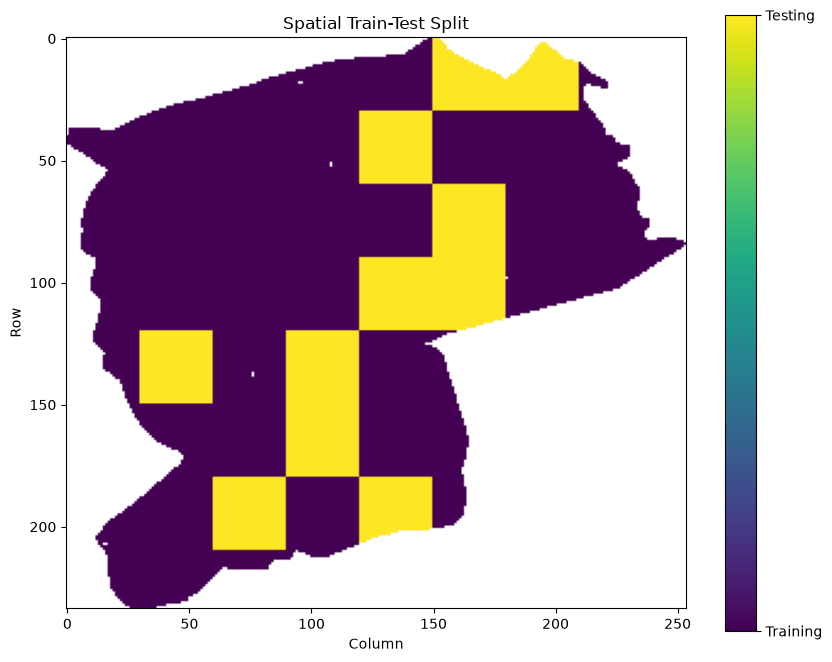

In [114]:
split_map = np.full(lst_90m.shape, np.nan)

# Training pixels
split_map[
    rows[train_mask],
    cols[train_mask]
] = 1

# Testing pixels
split_map[
    rows[test_mask],
    cols[test_mask]
] = 2

plt.figure(figsize=(10, 8))

plt.imshow(split_map, origin="upper")

cbar = plt.colorbar()
cbar.set_ticks([1, 2])
cbar.set_ticklabels(["Training", "Testing"])

plt.title("Spatial Train-Test Split")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

In [115]:
print("Training observations:", train_mask.sum())
print("Testing observations:", test_mask.sum())

print(
    "Training percentage:",
    train_mask.sum() / len(block_ids) * 100
)

print(
    "Testing percentage:",
    test_mask.sum() / len(block_ids) * 100
)

print(
    "Train/test block overlap:",
    len(set(train_blocks) & set(test_blocks))
)

Training observations: 26240
Testing observations: 9143
Training percentage: 74.15990730011588
Testing percentage: 25.840092699884128
Train/test block overlap: 0


### Observation

The spatial blocking procedure produced 55 spatial blocks.

Whole spatial blocks were assigned to either training or testing data rather than randomly splitting individual pixels. This reduces the risk of spatial leakage caused by neighboring pixels appearing in both datasets.

The final split contains 26,240 training observations and 9,143 testing observations, with no overlap between training and testing blocks.

### 3. Random Forest Baseline

A Random Forest regression model is trained using the spatially separated training dataset.

The predictors are:

- Green reflectance
- SWIR1 reflectance
- SWIR2 reflectance
- NDVI
- NDBI
- MNDWI

The target variable is 90 m coarse-resolution LST.

The model is evaluated on spatially withheld test blocks to assess its ability to generalize to unseen spatial regions.

In [116]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [117]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [118]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [119]:
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

In [120]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return mae, rmse, r2

In [121]:
train_mae, train_rmse, train_r2 = calculate_metrics(
    y_train,
    y_train_pred
)

test_mae, test_rmse, test_r2 = calculate_metrics(
    y_test,
    y_test_pred
)

In [122]:
print("Random Forest Performance")
print("-" * 40)

print("\nTraining:")
print(f"MAE  : {train_mae:.3f} °C")
print(f"RMSE : {train_rmse:.3f} °C")
print(f"R²   : {train_r2:.3f}")

print("\nTesting:")
print(f"MAE  : {test_mae:.3f} °C")
print(f"RMSE : {test_rmse:.3f} °C")
print(f"R²   : {test_r2:.3f}")

Random Forest Performance
----------------------------------------

Training:
MAE  : 0.232 °C
RMSE : 0.304 °C
R²   : 0.951

Testing:
MAE  : 0.742 °C
RMSE : 0.968 °C
R²   : 0.684


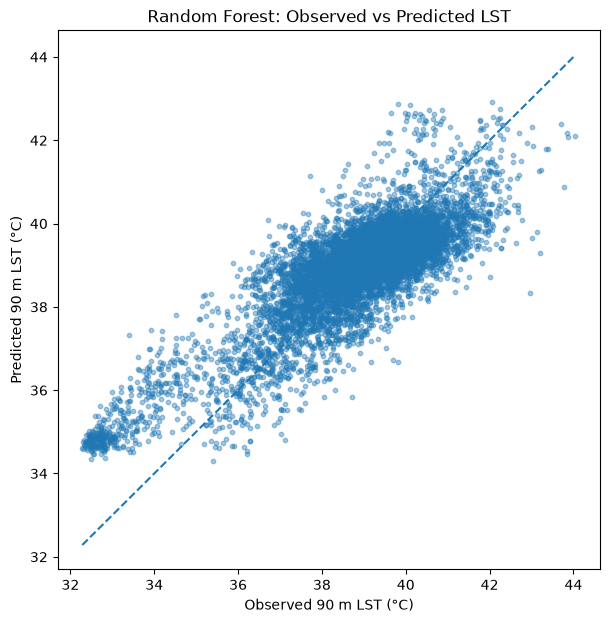

In [123]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_test_pred,
    s=10,
    alpha=0.4
)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed 90 m LST (°C)")
plt.ylabel("Predicted 90 m LST (°C)")
plt.title("Random Forest: Observed vs Predicted LST")

plt.show()

### Random Forest Results

The Random Forest achieved the following performance:

| Dataset | MAE (°C) | RMSE (°C) | R² |
|---|---:|---:|---:|
| Training | 0.232 | 0.304 | 0.951 |
| Spatial Test | 0.742 | 0.968 | 0.684 |

### Observation

The Random Forest performs strongly on the training data but shows a noticeable decrease in performance on the spatially withheld test regions.

The spatial test MAE of 0.742 °C indicates that the model captures the general relationship between the spectral predictors and 90 m LST, while the test R² of 0.684 indicates moderate predictive performance on unseen spatial blocks.

The difference between training and testing performance also indicates some degree of model overfitting. Therefore, the training metrics should not be interpreted as evidence of generalization; the spatial test metrics are the primary baseline for comparison with XGBoost.

In [124]:
residuals = y_test_pred - y_test

print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Residual minimum:", residuals.min())
print("Residual maximum:", residuals.max())

Residual mean: 0.07812443781439703
Residual std: 0.9648939865687551
Residual minimum: -4.6135110982259135
Residual maximum: 3.933964856465657


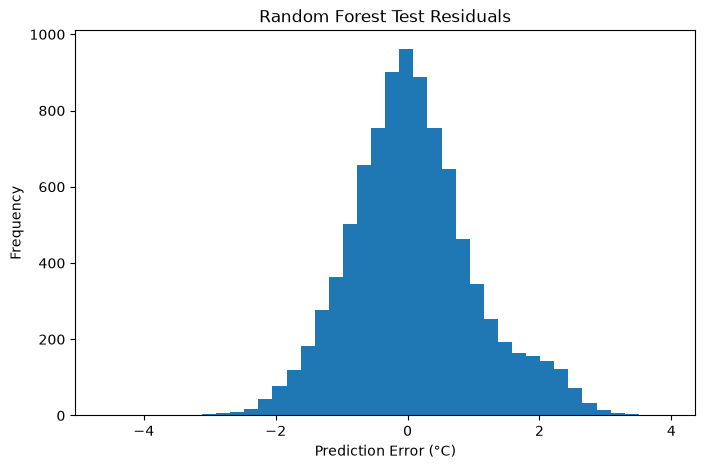

In [125]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=40)

plt.xlabel("Prediction Error (°C)")
plt.ylabel("Frequency")
plt.title("Random Forest Test Residuals")

plt.show()

### Residual Analysis — Observation

The mean residual is close to zero (0.078 °C), indicating only a small overall bias.

However, the residual range extends from approximately −4.61 °C to +3.93 °C, showing that some spatial observations have substantially larger prediction errors.

The residual distribution therefore suggests that although the Random Forest captures the general LST pattern, its performance is not uniform across all thermal conditions.

In [126]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(importance_df)

  feature  importance
2   swir2    0.552564
4    ndbi    0.162632
3    ndvi    0.081586
5   mndwi    0.072112
1   swir1    0.067702
0   green    0.063405


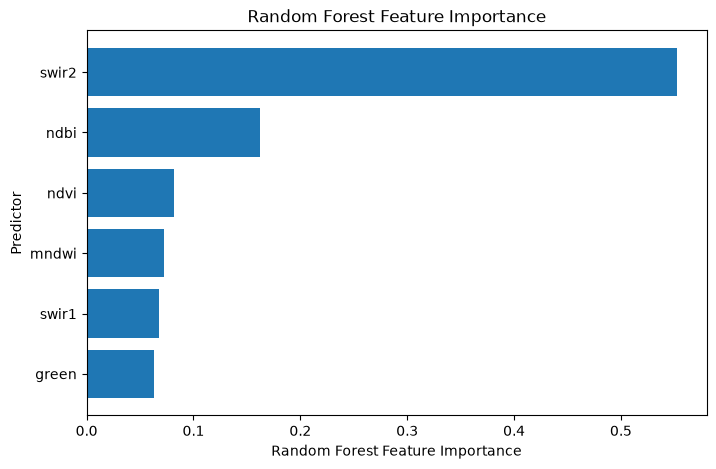

In [127]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

### Observation

SWIR2 has the highest impurity-based Random Forest feature importance (0.553), followed by NDBI (0.163) and NDVI (0.082).

However, these values should not be interpreted as the percentage contribution of each predictor to LST. Impurity-based feature importance can be affected by predictor characteristics and correlations between variables.

A more detailed interpretation of predictor influence will therefore be performed later using SHAP analysis.

In [128]:
correlation_matrix = df[feature_names + ["lst_90m"]].corr()

print(correlation_matrix.round(3))

         green  swir1  swir2   ndvi   ndbi  mndwi  lst_90m
green    1.000  0.729  0.892 -0.840  0.617 -0.052    0.664
swir1    0.729  1.000  0.918 -0.349  0.192 -0.717    0.574
swir2    0.892  0.918  1.000 -0.657  0.517 -0.432    0.718
ndvi    -0.840 -0.349 -0.657  1.000 -0.917 -0.345   -0.658
ndbi     0.617  0.192  0.517 -0.917  1.000  0.358    0.604
mndwi   -0.052 -0.717 -0.432 -0.345  0.358  1.000   -0.165
lst_90m  0.664  0.574  0.718 -0.658  0.604 -0.165    1.000


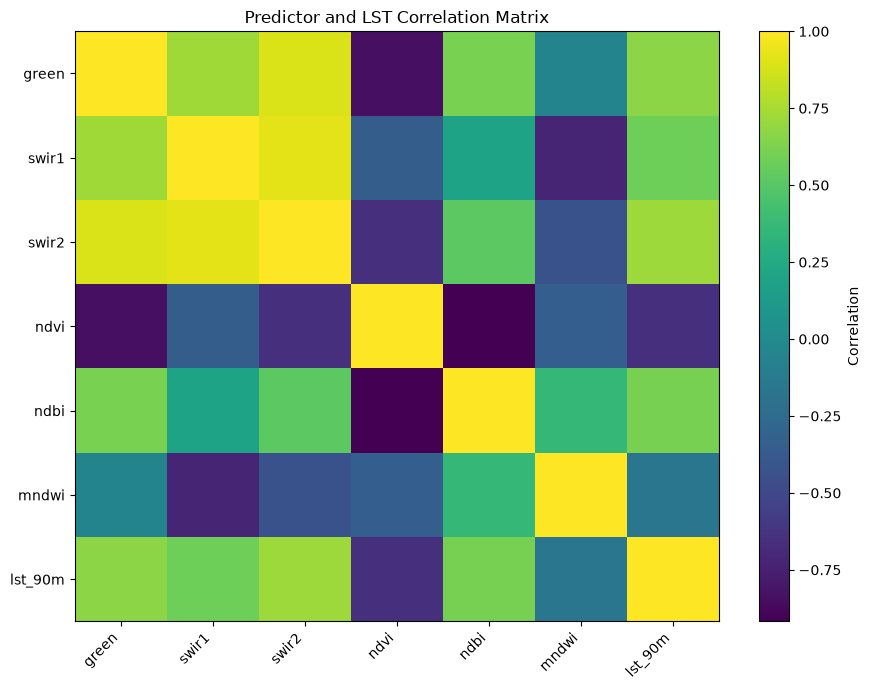

In [129]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation_matrix, aspect="auto")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.colorbar(label="Correlation")

plt.title("Predictor and LST Correlation Matrix")

plt.tight_layout()
plt.show()

In [130]:
comparison_df = pd.DataFrame({
    "observed": y_test,
    "predicted": y_test_pred
})

comparison_df["residual"] = (
    comparison_df["predicted"]
    - comparison_df["observed"]
)

comparison_df["observed_bin"] = pd.qcut(
    comparison_df["observed"],
    q=5,
    duplicates="drop"
)

bin_summary = comparison_df.groupby(
    "observed_bin",
    observed=True
).agg(
    observed_mean=("observed", "mean"),
    predicted_mean=("predicted", "mean"),
    mae=("residual", lambda x: np.mean(np.abs(x))),
    count=("residual", "size")
)

print(bin_summary)

                              observed_mean  predicted_mean       mae  count
observed_bin                                                                
(32.282000000000004, 37.814]      36.172283       37.221939  1.222775   1829
(37.814, 38.79]                   38.370266       38.729014  0.640997   1829
(38.79, 39.349]                   39.083233       39.134802  0.412665   1829
(39.349, 40.003]                  39.649368       39.408811  0.470341   1827
(40.003, 44.048]                  40.711414       39.882279  0.963415   1829


### Temperature-Range Observation

Prediction performance varies across the observed LST range.

The Random Forest tends to overpredict cooler observations and underpredict hotter observations. The coolest temperature group has an MAE of approximately 1.22 °C, while the hottest group has an MAE of approximately 0.96 °C.

The lowest errors occur in the middle temperature ranges. This indicates a regression-to-the-mean effect, where the model has difficulty reproducing the full range of thermal extremes.

### 4. Generate 30 m Random Forest LST

The trained Random Forest model is applied to the original 30 m predictor rasters to generate a 30 m LST product.

### 30 m Prediction

After training on the 90 m coarse-resolution dataset, the Random Forest is applied to the original 30 m predictor rasters.

This produces a spatially detailed 30 m LST estimate using the relationships learned from the 90 m training data.

The resulting raster represents the Random Forest downscaled LST product and is saved as a GeoTIFF for further analysis.

In [131]:
fine_data = {}

for name, path in predictor_paths.items():

    with rasterio.open(path) as src:
        fine_data[name] = src.read(1).astype(np.float32)

        if name == "green":
            fine_profile = src.profile.copy()
            fine_shape = src.shape
            fine_transform = src.transform
            fine_crs = src.crs

print("Fine grid shape:", fine_shape)
print("Fine CRS:", fine_crs)
print("Fine resolution:", fine_profile["transform"].a, abs(fine_profile["transform"].e))

Fine grid shape: (703, 762)
Fine CRS: EPSG:32644
Fine resolution: 30.0 30.0


In [132]:
fine_mask = np.ones(fine_shape, dtype=bool)

for name in ["green", "swir1", "swir2"]:

    fine_mask &= (
        np.isfinite(fine_data[name])
        & (fine_data[name] != 0)
    )

for name in ["ndvi", "ndbi", "mndwi"]:

    fine_mask &= np.isfinite(fine_data[name])

print("Total 30 m pixels:", fine_mask.size)
print("Valid 30 m predictor pixels:", fine_mask.sum())
print(
    "Valid percentage:",
    fine_mask.sum() / fine_mask.size * 100
)

Total 30 m pixels: 535686
Valid 30 m predictor pixels: 314853
Valid percentage: 58.775663355025145


In [133]:
X_fine = np.column_stack([
    fine_data["green"][fine_mask],
    fine_data["swir1"][fine_mask],
    fine_data["swir2"][fine_mask],
    fine_data["ndvi"][fine_mask],
    fine_data["ndbi"][fine_mask],
    fine_data["mndwi"][fine_mask]
])

print("Fine prediction matrix:", X_fine.shape)

Fine prediction matrix: (314853, 6)


In [134]:
lst_30m_pred = rf_model.predict(X_fine)

print("Predicted 30 m LST")
print("Minimum:", lst_30m_pred.min())
print("Maximum:", lst_30m_pred.max())
print("Mean:", lst_30m_pred.mean())
print("Std:", lst_30m_pred.std())

Predicted 30 m LST
Minimum: 33.09056416829427
Maximum: 44.17073267618815
Mean: 39.22078832336607
Std: 1.3530493272949424


In [135]:
lst_rf_30m = np.full(
    fine_shape,
    np.nan,
    dtype=np.float32
)

lst_rf_30m[fine_mask] = lst_30m_pred

print("Output raster shape:", lst_rf_30m.shape)

Output raster shape: (703, 762)


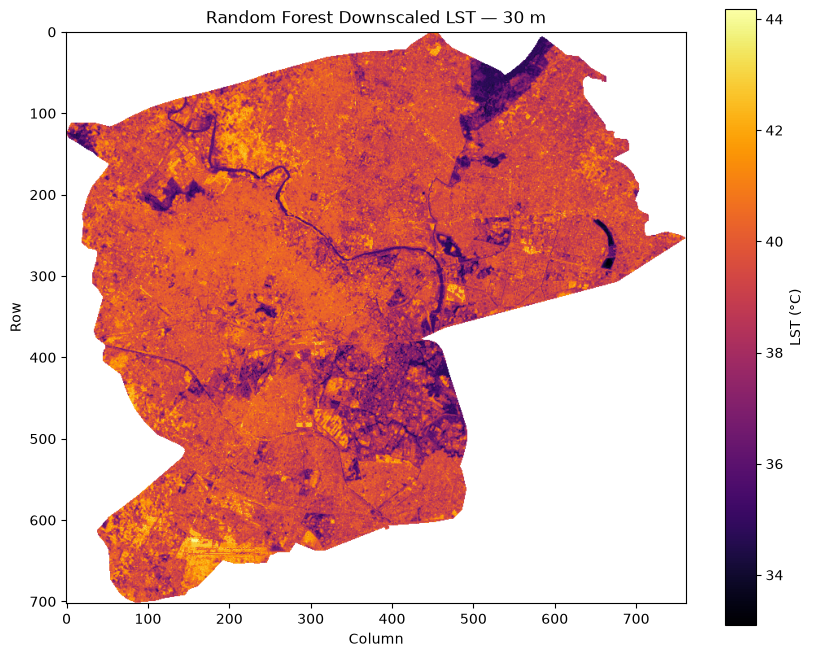

In [136]:
plt.figure(figsize=(10, 8))

plt.imshow(lst_rf_30m, cmap="inferno")
plt.colorbar(label="LST (°C)")

plt.title("Random Forest Downscaled LST — 30 m")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

In [137]:
rf_30m_output = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "lucknow"
    / "downscaled"
    / "rf_lst_30m_lucknow.tif"
)

In [138]:
rf_30m_output.parent.mkdir(
    parents=True,
    exist_ok=True
)

In [139]:
rf_profile = fine_profile.copy()

rf_profile.update(
    dtype="float32",
    count=1,
    nodata=np.nan
)

with rasterio.open(
    rf_30m_output,
    "w",
    **rf_profile
) as dst:

    dst.write(
        lst_rf_30m.astype(np.float32),
        1
    )

print("Saved RF 30 m LST:")
print(rf_30m_output)

Saved RF 30 m LST:
D:\Projects\GeoAI-LST-Downscaling\data\processed\lucknow\downscaled\rf_lst_30m_lucknow.tif


In [140]:
# Aggregate the 30 m RF prediction back to 90 m

rf_90m_from_30m = aggregate_30m_to_90m(
    lst_rf_30m,
    nodata=np.nan
)

print("RF 90 m reconstructed shape:", rf_90m_from_30m.shape)

print("Minimum:", np.nanmin(rf_90m_from_30m))
print("Maximum:", np.nanmax(rf_90m_from_30m))
print("Mean:", np.nanmean(rf_90m_from_30m))
print("Std:", np.nanstd(rf_90m_from_30m))

RF 90 m reconstructed shape: (234, 254)
Minimum: 33.32992
Maximum: 44.041016
Mean: 39.217323
Std: 1.1779268


In [141]:
consistency_mask = (
    np.isfinite(rf_90m_from_30m)
    & np.isfinite(lst_90m)
    & (lst_90m != -9999)
)

original_90m = lst_90m[consistency_mask]
reconstructed_90m = rf_90m_from_30m[consistency_mask]

print("Valid comparison pixels:", len(original_90m))

Valid comparison pixels: 35383


In [142]:
consistency_mae = mean_absolute_error(
    original_90m,
    reconstructed_90m
)

consistency_rmse = np.sqrt(
    mean_squared_error(
        original_90m,
        reconstructed_90m
    )
)

consistency_r2 = r2_score(
    original_90m,
    reconstructed_90m
)

print("\n30 m → 90 m Consistency")
print("-" * 40)
print(f"MAE  : {consistency_mae:.3f} °C")
print(f"RMSE : {consistency_rmse:.3f} °C")
print(f"R²   : {consistency_r2:.3f}")


30 m → 90 m Consistency
----------------------------------------
MAE  : 0.637 °C
RMSE : 0.829 °C
R²   : 0.691


### 30 m → 90 m Consistency — Observation

The 30 m Random Forest LST was aggregated back to the 90 m grid and compared with the original 90 m LST target.

The reconstructed product achieved:

- MAE: 0.637 °C
- RMSE: 0.829 °C
- R²: 0.691

The reconstructed 90 m product shows a strong correspondence with the original coarse-resolution LST, indicating that the generated 30 m product retains substantial consistency with the target thermal field.

However, this is a consistency assessment rather than an independent validation metric. The independent spatial test performance remains the primary measure of model generalization.

In [143]:
print("\nOriginal 90 m LST")
print("Min :", np.nanmin(original_90m))
print("Max :", np.nanmax(original_90m))
print("Mean:", np.nanmean(original_90m))
print("Std :", np.nanstd(original_90m))

print("\nReconstructed 90 m RF LST")
print("Min :", np.nanmin(reconstructed_90m))
print("Max :", np.nanmax(reconstructed_90m))
print("Mean:", np.nanmean(reconstructed_90m))
print("Std :", np.nanstd(reconstructed_90m))


Original 90 m LST
Min : 32.28329
Max : 44.784115
Mean: 39.171635
Std : 1.4903706

Reconstructed 90 m RF LST
Min : 33.32992
Max : 44.041016
Mean: 39.217445
Std : 1.1778954


In [144]:
PROJECT_ROOT = Path(r"D:\Projects\GeoAI-LST-Downscaling")   
FIGURES_DIR = PROJECT_ROOT / "figures"/ "lucknow"/ "notebook_4"


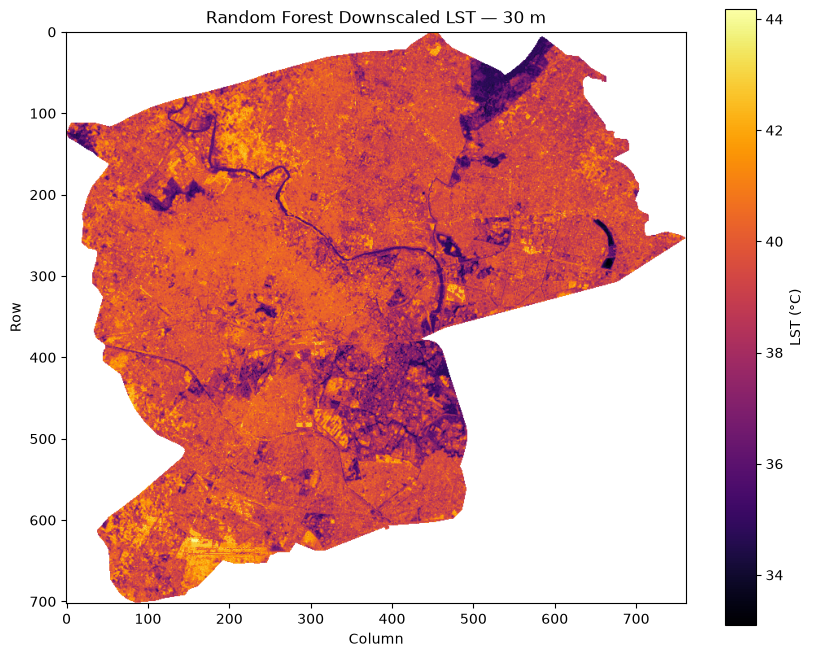

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_4\rf_lst_30m_lucknow.png


In [145]:
from pathlib import Path

figures_dir = PROJECT_ROOT / "figures" / "lucknow" / "notebook_4"
figures_dir.mkdir(parents=True, exist_ok=True)

rf_lst_png = figures_dir / "rf_lst_30m_lucknow.png"

plt.figure(figsize=(10, 8))

plt.imshow(lst_rf_30m, cmap="inferno")
plt.colorbar(label="LST (°C)")

plt.title("Random Forest Downscaled LST — 30 m")
plt.xlabel("Column")
plt.ylabel("Row")

plt.savefig(
    rf_lst_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", rf_lst_png)

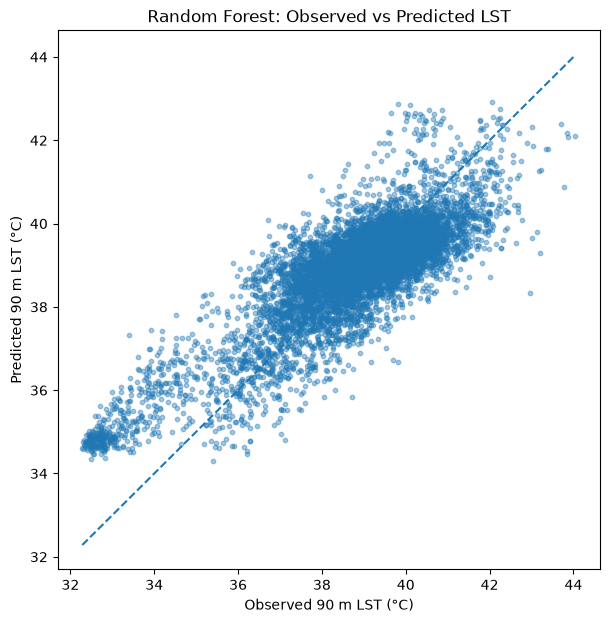

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_4\rf_observed_vs_predicted.png


In [146]:
scatter_png = figures_dir / "rf_observed_vs_predicted.png"

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_test_pred,
    s=10,
    alpha=0.4
)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Observed 90 m LST (°C)")
plt.ylabel("Predicted 90 m LST (°C)")
plt.title("Random Forest: Observed vs Predicted LST")

plt.savefig(
    scatter_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", scatter_png)

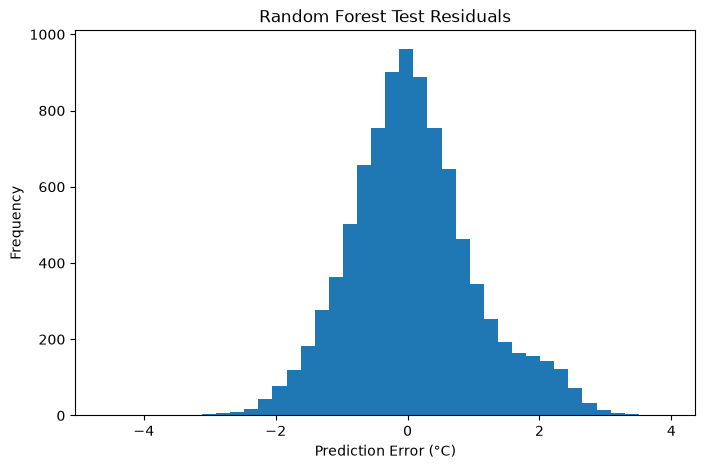

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_4\rf_residuals.png


In [147]:
residual_png = figures_dir / "rf_residuals.png"

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=40)

plt.xlabel("Prediction Error (°C)")
plt.ylabel("Frequency")
plt.title("Random Forest Test Residuals")

plt.savefig(
    residual_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", residual_png)

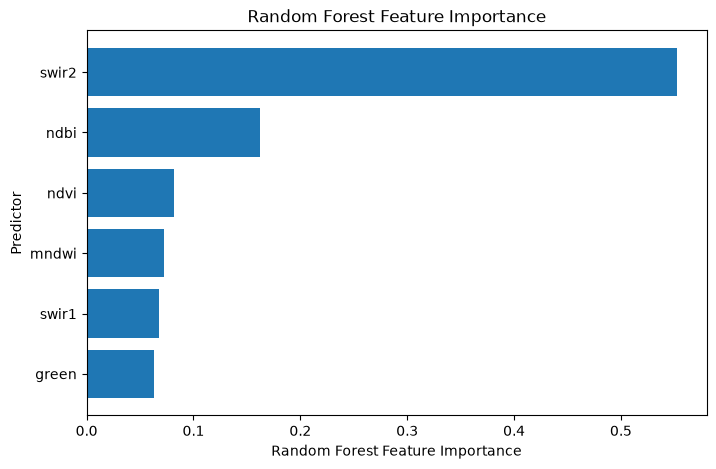

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_4\rf_feature_importance.png


In [148]:
importance_png = figures_dir / "rf_feature_importance.png"

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.savefig(
    importance_png,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", importance_png)

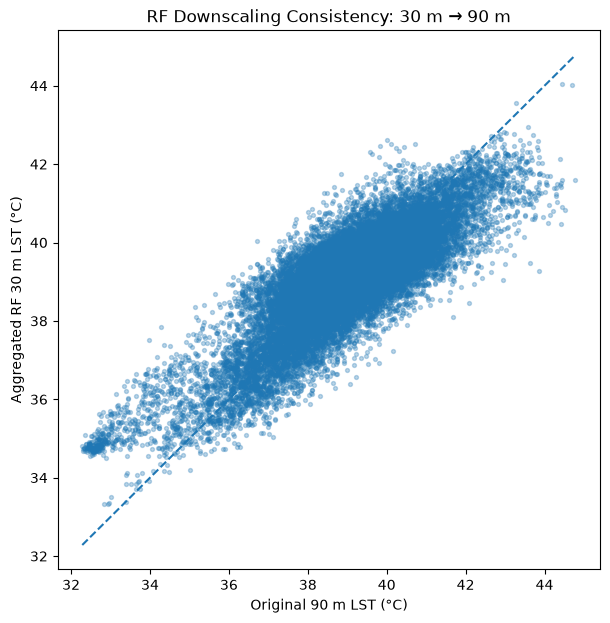

Saved: D:\Projects\GeoAI-LST-Downscaling\figures\lucknow\notebook_4\rf_consistency_30m.png


In [149]:
consistency_png_path = FIGURES_DIR / "rf_consistency_30m.png"

plt.figure(figsize=(7, 7))

plt.scatter(
    original_90m,
    reconstructed_90m,
    s=8,
    alpha=0.3
)

min_val = min(
    original_90m.min(),
    reconstructed_90m.min()
)

max_val = max(
    original_90m.max(),
    reconstructed_90m.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Original 90 m LST (°C)")
plt.ylabel("Aggregated RF 30 m LST (°C)")
plt.title("RF Downscaling Consistency: 30 m → 90 m")

plt.savefig(
    consistency_png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", consistency_png_path)

In [150]:
with rasterio.open(rf_30m_output) as src:

    saved_rf = src.read(1)

    print("RF 30 m GeoTIFF")
    print("----------------------------")
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Dtype:", src.dtypes[0])
    print("NoData:", src.nodata)
    print("Transform:", src.transform)

    valid = saved_rf[np.isfinite(saved_rf)]

    print("\nValue statistics")
    print("Min:", valid.min())
    print("Max:", valid.max())
    print("Mean:", valid.mean())
    print("Std:", valid.std())

RF 30 m GeoTIFF
----------------------------
Shape: (703, 762)
CRS: EPSG:32644
Resolution: (30.0, 30.0)
Dtype: float32
NoData: nan
Transform: | 30.00, 0.00, 483225.00|
| 0.00,-30.00, 2979165.00|
| 0.00, 0.00, 1.00|

Value statistics
Min: 33.090565
Max: 44.170734
Mean: 39.220787
Std: 1.3530493


## Summary and Key Observations

The Random Forest baseline successfully generated a 30 m LST product for Lucknow using six remote-sensing predictors.

### Key Results

| Metric | Result |
|---|---:|
| Valid ML observations | 35,383 |
| Spatial blocks | 55 |
| Training observations | 26,240 |
| Testing observations | 9,143 |
| Spatial test MAE | 0.742 °C |
| Spatial test RMSE | 0.968 °C |
| Spatial test R² | 0.684 |
| 30 m → 90 m MAE | 0.637 °C |
| 30 m → 90 m RMSE | 0.829 °C |
| 30 m → 90 m R² | 0.691 |

### Main Observations

1. The Random Forest provides a useful baseline for LST downscaling, achieving a spatial test R² of 0.684.

2. The model shows some overfitting, with substantially better training performance than spatial test performance.

3. Prediction errors are larger toward the cooler and hotter ends of the observed LST range, indicating regression toward the mean.

4. SWIR2 is the most influential predictor according to impurity-based Random Forest feature importance, followed by NDBI and NDVI.

5. The 30 m RF product remains reasonably consistent with the original 90 m LST after aggregation back to the coarse grid.

6. The Random Forest results will serve as the baseline for comparison with the XGBoost model in the next stage.